# Đánh giá mô hình NLI: Base Model vs. Fine-tuned BamiBERT

- **Thư mục root**: `ML_final`
- **Dataset đánh giá**: `src/db/eval/vlsp_nli.parquet`
- **Mô hình gốc (Base)**: `Qualcomm-AI-Research/BamiBERT`
- **Mô hình Fine-tuned**: `src/be/NLIProvider/models/bamibert_vilegalnli`
- **Quy ước nhãn**: `choices = ['Có', 'Không']` -> `answer = 0` ('Có') tương ứng **Entailment (1)**, `answer = 1` ('Không') tương ứng **Non-entailment / Contradiction (0)**.

In [1]:
import os
import sys
from pathlib import Path

# Đảm bảo ML_final nằm trong sys.path khi chạy notebook
CURRENT_DIR = Path.cwd().resolve()
for p in [CURRENT_DIR, *CURRENT_DIR.parents]:
    if (p / "be" / "src").is_dir() and (p / "pyproject.toml").is_file():
        if str(p) not in sys.path:
            sys.path.insert(0, str(p))
        os.chdir(str(p))
        break

print(f"📁 Thư mục làm việc hiện tại: {Path.cwd()}")

📁 Thư mục làm việc hiện tại: C:\Users\VINH\OneDrive - VNU-HCMUS\Attachments\Desktop\ML_final


In [ ]:
import torch
import pandas as pd
import numpy as np
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report

from be.src.config.config import config

DATASET_PATH = Path("db/eval/vlsp_nli.parquet")
FINETUNED_MODEL_PATH = Path("be/src/NLIProvider/models/bamibert_vilegalnli")
BASE_MODEL_PATH = "Qualcomm-AI-Research/BamiBERT"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"🎯 Thiết bị thực thi: {device}")
print(f"📊 Dataset: {DATASET_PATH}")
print(f"🤖 Fine-tuned Model: {FINETUNED_MODEL_PATH}")

c:\Users\VINH\OneDrive - VNU-HCMUS\Attachments\Desktop\ML_final\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🎯 Thiết bị thực thi: cuda
📊 Dataset: db\eval\vlsp_nli.parquet
🤖 Fine-tuned Model: be\src\NLIProvider\models\bamibert_vilegalnli_best


## 1. Nạp và xử lý tập dữ liệu kiểm thử

In [3]:
# Đọc dataset từ src/db/eval/vlsp_nli.parquet
df = pd.read_parquet(DATASET_PATH)

# Ánh xạ nhãn: answer 0 ('Có') -> 1 (Entailment), answer 1 ('Không') -> 0 (Non-entailment)
if "choices" in df.columns:
    df["nli_label"] = df["answer"].apply(lambda x: 1 if x == 0 else 0)
else:
    df["nli_label"] = df["answer"]

label_col = "nli_label"

print(f"Tổng số mẫu kiểm thử: {len(df)}")
print("\nPhân phối nhãn (1: Entailment, 0: Non-entailment):")
print(df[label_col].value_counts())
print("\nMẫu dữ liệu đầu tiên:")
df[["specific_question", "legal_document", "answer", label_col]].head()

Tổng số mẫu kiểm thử: 150

Phân phối nhãn (1: Entailment, 0: Non-entailment):
nli_label
1    75
0    75
Name: count, dtype: int64

Mẫu dữ liệu đầu tiên:


,specific_question,legal_document,answer,nli_label
0,Khi nào sẽ có 5 bảng lương mới theo cải cách t...,Theo Kết luận 83-KL/TW năm 2024 có nêu sau năm...,0,1
1,Cổ đông có những nghĩa vụ gì theo quy định của...,Căn cứ Điều 119 Luật Doanh nghiệp 2020 quy địn...,0,1
2,So sánh mức độ cắt giảm thời gian và chi phí t...,"Theo Thông báo 294/TB-VPCP năm 2025, Chính phủ...",0,1
3,Quy trình trình Bộ trưởng Bộ Tài chính xem xét...,Căn cứ tại khoản 2 Điều 2 Quyết định 383/QĐ-BT...,0,1
4,Hậu quả pháp lý khi doanh nghiệp có giao dịch ...,Căn cứ Điều 16 Nghị định 132/2020/NĐ-CP quy đị...,0,1


## 2. Hàm suy luận và đánh giá theo Batch

In [4]:
from transformers import RobertaTokenizerFast

def get_tokenizer(model_name_or_path):
    try:
        return AutoTokenizer.from_pretrained(str(model_name_or_path))
    except Exception:
        return RobertaTokenizerFast.from_pretrained(str(model_name_or_path))

def evaluate_model(model_name_or_path, df, batch_size=16, max_length=2048):
    print(f"\n>>> Đang nạp model và tokenizer từ: {model_name_or_path}")
    tokenizer = get_tokenizer(model_name_or_path)
    
    model = AutoModelForSequenceClassification.from_pretrained(
        str(model_name_or_path),
        num_labels=2,
        ignore_mismatched_sizes=True
    ).to(device)
    model.eval()
    
    predictions = []
    
    for i in tqdm(range(0, len(df), batch_size), desc=f"Đang đánh giá {Path(str(model_name_or_path)).name}"):
        batch = df.iloc[i : i + batch_size]
        premises = batch["specific_question"].tolist()
        hypotheses = batch["legal_document"].tolist()
        
        inputs = tokenizer(
            premises,
            hypotheses,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits
            
        preds = torch.argmax(logits, dim=-1).cpu().numpy()
        predictions.extend(preds)
        
    return predictions


## 3. Thực thi đánh giá Base Model vs Fine-tuned Model

In [5]:
print("=== 1. ĐÁNH GIÁ BASE MODEL (BamiBERT) ===")
base_preds = evaluate_model(BASE_MODEL_PATH, df)

print("\n=== 2. ĐÁNH GIÁ FINE-TUNED MODEL (BamiBERT-ViLegalNLI) ===")
finetuned_preds = evaluate_model(FINETUNED_MODEL_PATH, df)

=== 1. ĐÁNH GIÁ BASE MODEL (BamiBERT) ===

>>> Đang nạp model và tokenizer từ: Qualcomm-AI-Research/BamiBERT


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 2574.65it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: Qualcomm-AI-Research/BamiBERT
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.decoder.bias       | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Đang đánh giá BamiBERT: 100%|██████████| 10/10 [00:08<00:00,  1.15it/s]


=== 2. ĐÁNH GIÁ FINE-TUNED MODEL (BamiBERT-ViLegalNLI) ===

>>> Đang nạp model và tokenizer từ: be\src\NLIProvider\models\bamibert_vilegalnli_best


Đang đánh giá bamibert_vilegalnli_best: 100%|██████████| 10/10 [00:02<00:00,  4.08it/s]


## 4. Tổng hợp và so sánh kết quả Metrics

In [6]:
def calculate_metrics(y_true, y_pred):
    return {
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
        "Recall": round(recall_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
        "F1-Score": round(f1_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
        "Macro F1": round(f1_score(y_true, y_pred, average="macro", zero_division=0), 4)
    }

y_true = df[label_col].tolist()

base_metrics = calculate_metrics(y_true, base_preds)
finetuned_metrics = calculate_metrics(y_true, finetuned_preds)

comparison_df = pd.DataFrame([
    {"Model": "Base Model (BamiBERT)", **base_metrics},
    {"Model": "Fine-tuned Model (BamiBERT-ViLegalNLI)", **finetuned_metrics}
])

print("\n" + "=" * 65)
print("                    BẢNG TỔNG HỢP SO SÁNH")
print("=" * 65)
print(comparison_df.to_string(index=False))

print("\n" + "-" * 65)
print("Chi tiết Classification Report: Base Model")
print("-" * 65)
print(classification_report(y_true, base_preds, target_names=["Non-entailment (0)", "Entailment (1)"], zero_division=0))

print("-" * 65)
print("Chi tiết Classification Report: Fine-tuned Model")
print("-" * 65)
print(classification_report(y_true, finetuned_preds, target_names=["Non-entailment (0)", "Entailment (1)"], zero_division=0))


                    BẢNG TỔNG HỢP SO SÁNH
                                 Model  Accuracy  Precision  Recall  F1-Score  Macro F1
                 Base Model (BamiBERT)      0.50     0.5000  1.0000    0.6667    0.3333
Fine-tuned Model (BamiBERT-ViLegalNLI)      0.78     0.7625  0.8133    0.7871    0.7798

-----------------------------------------------------------------
Chi tiết Classification Report: Base Model
-----------------------------------------------------------------
                    precision    recall  f1-score   support

Non-entailment (0)       0.00      0.00      0.00        75
    Entailment (1)       0.50      1.00      0.67        75

          accuracy                           0.50       150
         macro avg       0.25      0.50      0.33       150
      weighted avg       0.25      0.50      0.33       150

-----------------------------------------------------------------
Chi tiết Classification Report: Fine-tuned Model
---------------------------------------

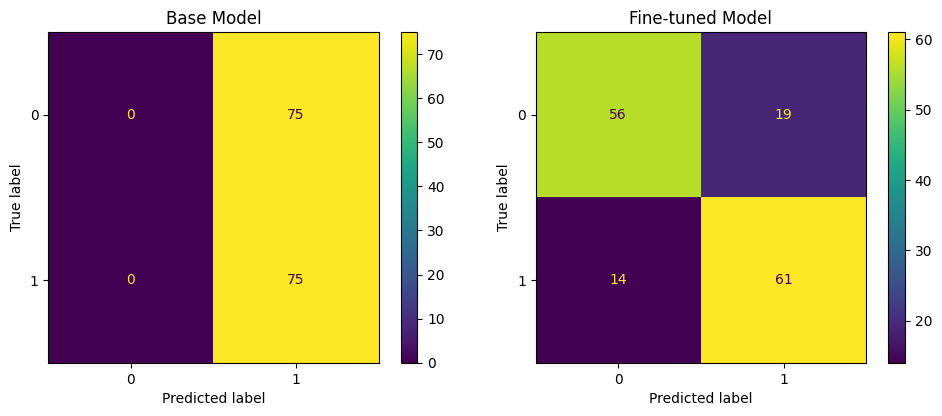

In [7]:
import matplotlib.pyplot as plt
from sklearn import metrics

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# 2. Base Model
cm_base = metrics.confusion_matrix(y_true, base_preds)
cm_display_base = metrics.ConfusionMatrixDisplay(confusion_matrix=cm_base, display_labels=[0, 1])
cm_display_base.plot(ax=ax1, values_format="d")
ax1.set_title("Base Model")

# 3. Fine-tuned Model
cm_finetuned = metrics.confusion_matrix(y_true, finetuned_preds)
cm_display_finetuned = metrics.ConfusionMatrixDisplay(confusion_matrix=cm_finetuned, display_labels=[0, 1])
cm_display_finetuned.plot(ax=ax2, values_format="d")
ax2.set_title("Fine-tuned Model")

plt.tight_layout()
plt.show()
